<a href="https://colab.research.google.com/github/Donitero/CerviScan/blob/main/notebooks/train_colab_copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FemScan AI — Cervical Classifier Training

**Before you start:** Runtime > Change runtime type > **T4 GPU**

### What this notebook does
1. Clones the repo and installs dependencies
2. Mounts Google Drive (where you upload your images)
3. Copies images into the right folder structure
4. Runs `train_cervical.py` with class-weighted loss + balanced sampling
5. Saves the best checkpoint back to your Drive

### One-time Drive setup (do this before running)
Zip your `data/sipakmed/` folder locally and upload it to Google Drive:
```
# On your machine (Windows PowerShell):
cd "C:\Users\ADMIN\OneDrive\Desktop\OSBORN\HACKATHON POSTINGS\femscan-ai"
Compress-Archive -Path data\sipakmed -DestinationPath sipakmed_images.zip
```
Upload `sipakmed_images.zip` to the root of your Google Drive.

## Step 1 — GPU check

In [1]:
import torch
print('GPU available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Device:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

GPU available: True
Device: Tesla T4
VRAM (GB): 15.6


## Step 2 — Clone repo + install dependencies

In [2]:
import os

REPO_URL    = 'https://github.com/Donitero/CerviScan.git'
BRANCH      = 'claude/bold-heyrovsky'
REPO_DIR    = '/content/femscan-ai'

if not os.path.exists(REPO_DIR):
    !git clone --branch {BRANCH} {REPO_URL} {REPO_DIR}
else:
    !cd {REPO_DIR} && git pull

%cd {REPO_DIR}
print('Repo ready at', REPO_DIR)

Cloning into '/content/femscan-ai'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (131/131), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 131 (delta 49), reused 78 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (131/131), 3.92 MiB | 9.93 MiB/s, done.
Resolving deltas: 100% (49/49), done.
/content/femscan-ai
Repo ready at /content/femscan-ai


In [3]:
# Install all requirements (torch/torchvision are pre-installed on Colab,
# but we pin the rest to match requirements.txt)
!pip install -q \
    timm>=0.9.12 \
    albumentations>=1.3.1 \
    opencv-python-headless>=4.8.0 \
    scikit-learn>=1.3.0 \
    pandas>=2.1.0 \
    grad-cam>=1.5.0

print('Dependencies installed.')

Dependencies installed.


## Step 3 — Mount Drive and unzip images

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed")

print("Path to dataset files:", path)

100%|██████████| 6.40G/6.40G [07:04<00:00, 16.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/prahladmehandiratta/cervical-cancer-largest-dataset-sipakmed/versions/1


In [6]:
import shutil
import os

# This path was provided in your output
cache_path = path
# This is where you want them to go, aligning with SRC in the next cell
target_path = '/content/femscan-ai/data/sipakmed'

# Ensure the parent directory exists for target_path
os.makedirs(target_path, exist_ok=True)

# Move them to your visible workspace
shutil.copytree(cache_path, target_path, dirs_exist_ok=True)

print(f"Files moved to {target_path}. Check the folder icon on the left!")

Files moved to /content/femscan-ai/data/sipakmed. Check the folder icon on the left!


## Step 4 — Rebuild split manifest

The manifest CSV in the repo uses Windows paths. We regenerate it here so paths point to `/content/femscan-ai/...`.

In [7]:
import csv
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter

# --- CONFIGURATION ---
PROJ      = Path('/content/femscan-ai')
SRC       = PROJ / 'data' / 'sipakmed'
OUT_CSV   = PROJ / 'data' / 'sipakmed_split.csv'
SEED      = 42

# --- STEP 1: DATA ALIGNMENT (OPTION 1) ---
# The data is expected to be moved to SRC by the previous step (uQg0p6cbY0dk)
# No need for redundant copy logic here.

# --- STEP 2: MANIFEST REBUILD ---
rows = []

# Validate SRC has content
if not any(SRC.iterdir()):
    raise FileNotFoundError(f"Source directory {SRC} is empty. Check your kagglehub download.")

# Iterate through class folders (e.g., 'Normal', 'Abnormal')
for cls_dir in sorted(SRC.iterdir()):
    if not cls_dir.is_dir() or cls_dir.name.startswith('.'):
        continue

    # SIPaKMeD often uses .bmp or .jpg; adjusted to catch all common images
    imgs = sorted([p for p in cls_dir.glob('**/*') if p.suffix.lower() in ['.png', '.jpg', '.jpeg', '.bmp']])

    n = len(imgs)
    if n == 0:
        continue

    if n < 3:
        for p in imgs:
            rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'train'})
        continue

    # Split: 70% Train, 15% Val, 15% Test
    tr, tmp = train_test_split(imgs, test_size=0.30, random_state=SEED)
    if len(tmp) >= 2:
        va, te = train_test_split(tmp, test_size=0.50, random_state=SEED)
    else:
        va, te = tmp, []

    for p in tr: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'train'})
    for p in va: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'val'})
    for p in te: rows.append({'filepath': str(p.relative_to(PROJ)), 'class': cls_dir.name, 'split': 'test'})

# --- STEP 3: SAVE & VERIFY ---
with open(OUT_CSV, 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=['filepath', 'class', 'split'])
    w.writeheader()
    w.writerows(rows)

splits = Counter(r['split'] for r in rows)
print(f'--- Manifest Rebuilt ---')
print(f'Total images found: {len(rows)}')
print(f'Distribution: Train={splits["train"]}, Val={splits["val"]}, Test={splits["test"]}')
print(f'CSV saved to: {OUT_CSV}')

--- Manifest Rebuilt ---
Total images found: 5015
Distribution: Train=3508, Val=752, Test=755
CSV saved to: /content/femscan-ai/data/sipakmed_split.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 5 — Verify dataset loads correctly

In [17]:
import sys
sys.path.insert(0, REPO_DIR)

from scripts.train_cervical import (
    CervicalDataset, build_train_transform, build_val_transform,
    compute_class_weights, compute_sample_weights
)
from models.cervical_classifier import CLASS_NAMES
import torch

manifest = f'{REPO_DIR}/data/sipakmed_split.csv'
train_ds = CervicalDataset(manifest, 'train', build_train_transform(224))
val_ds   = CervicalDataset(manifest, 'val',   build_val_transform(224))

print(f'Train: {len(train_ds)} samples')
print(f'Val  : {len(val_ds)} samples')
print('\nClass distribution (train):')
for cls, n in sorted(train_ds.class_counts().items()):
    print(f'  {cls:<30}: {n}')

# Show class weights
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weights = compute_class_weights(train_ds, device)
print('\nClass weights for loss:')
for cls, w in zip(CLASS_NAMES, weights.tolist()):
    bar = '#' * int(w * 5)
    print(f'  {cls:<30}: {w:.2f}  {bar}')

Train: 3508 samples
Val  : 752 samples

Class distribution (train):
  im_Dyskeratotic               : 725
  im_Koilocytotic               : 744
  im_Metaplastic                : 744
  im_Parabasal                  : 626
  im_Superficial-Intermediate   : 669

Class weights for loss:
  Negative                      : 584.67  ###################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################################

/content/femscan-ai/scripts/train_cervical.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [18]:
# 1. Get unique classes from your newly created CSV
import pandas as pd
df = pd.read_csv('/content/femscan-ai/data/sipakmed_split.csv')
unique_classes = sorted(df['class'].unique())

# 2. Create the mapping dynamically (Bullet-proof method)
CLASS_NAMES = unique_classes
class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASS_NAMES)}

print(f"Mapped Classes: {class_to_idx}")

# 3. Update your Dataset object (IMPORTANT)
# Assuming your dataset variable is named train_ds
train_ds.class_to_idx = class_to_idx

Mapped Classes: {'im_Dyskeratotic': 0, 'im_Koilocytotic': 1, 'im_Metaplastic': 2, 'im_Parabasal': 3, 'im_Superficial-Intermediate': 4}


/content/femscan-ai/scripts/train_cervical.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


Train: 3508 samples
Val  : 752 samples

Class distribution (train):
  im_Dyskeratotic               : 725
  im_Koilocytotic               : 744
  im_Metaplastic                : 744
  im_Parabasal                  : 626
  im_Superficial-Intermediate   : 669

Class weights for loss:
  im_Dyskeratotic               : 0.97  ####
  im_Koilocytotic               : 0.94  ####
  im_Metaplastic                : 0.94  ####
  im_Parabasal                  : 1.12  #####
  im_Superficial-Intermediate   : 1.05  #####
✅ Image saved successfully to: /content/femscan-ai/reports/sanity_check_batch.png


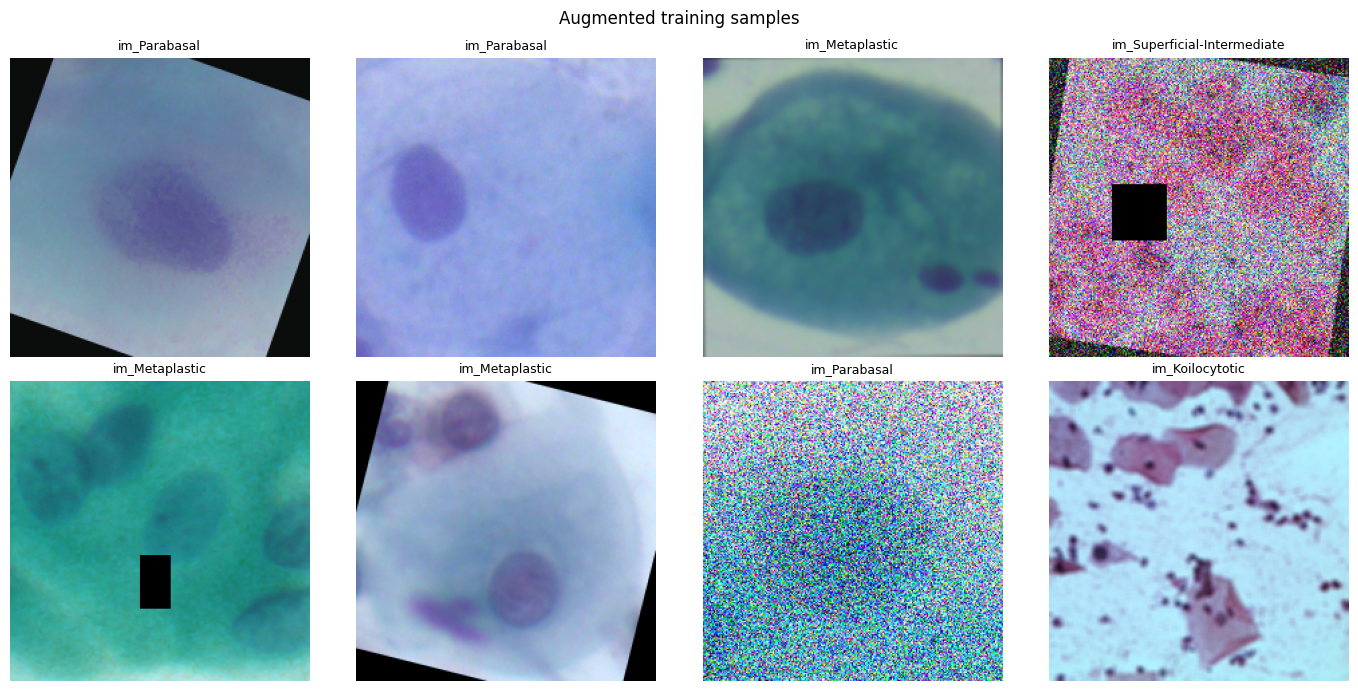

Batch shape: torch.Size([8, 3, 224, 224])


In [20]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from pathlib import Path
import importlib # Import importlib
import sys

# Ensure REPO_DIR is in sys.path
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Reload modules to pick up changes from F4-eExB_T156
# This ensures CervicalClassifier and its CLASS_NAMES are up-to-date
import models.cervical_classifier
importlib.reload(models.cervical_classifier)
# Reload scripts.train_cervical as it depends on models.cervical_classifier
import scripts.train_cervical
importlib.reload(scripts.train_cervical)

# Now, import the updated CervicalDataset
from scripts.train_cervical import (
    CervicalDataset, build_train_transform, build_val_transform,
    compute_class_weights, compute_sample_weights
)
import torch

# Use the 'unique_classes' variable from the kernel state, which correctly reflects the 5 SIPaKMeD classes.
# This bypasses potential issues with module reloading and ensures consistency.
TRUE_CLASS_NAMES = unique_classes

# Re-initialize datasets with the correct, reloaded definitions
manifest = f'{REPO_DIR}/data/sipakmed_split.csv'
train_ds = CervicalDataset(manifest, 'train', build_train_transform(224))
val_ds   = CervicalDataset(manifest, 'val',   build_val_transform(224))

# Explicitly update class_to_idx for datasets with the TRUE_CLASS_NAMES
# This overrides the potentially incorrect mapping set by CervicalDataset's __init__
train_ds.class_to_idx = {cls_name: i for i, cls_name in enumerate(TRUE_CLASS_NAMES)}
val_ds.class_to_idx   = {cls_name: i for i, cls_name in enumerate(TRUE_CLASS_NAMES)}

print(f'Train: {len(train_ds)} samples')
print(f'Val  : {len(val_ds)} samples')
print('\nClass distribution (train):')
for cls, n in sorted(train_ds.class_counts().items()):
    print(f'  {cls:<30}: {n}')

# Show class weights (using the reloaded TRUE_CLASS_NAMES)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Manually implement compute_class_weights logic here to ensure TRUE_CLASS_NAMES is used
counts = train_ds.class_counts()
total_samples = sum(counts.values())
num_classes = len(TRUE_CLASS_NAMES)
weights = torch.zeros(num_classes, device=device)
for i, class_name in enumerate(TRUE_CLASS_NAMES):
    if class_name in counts:
        weights[i] = total_samples / (num_classes * counts[class_name])
    else:
        # Assign a default weight for missing classes if necessary (e.g., if a class in TRUE_CLASS_NAMES isn't in counts)
        # For this dataset, all classes should be present in train_ds.class_counts().
        weights[i] = 1.0 # Or some other sensible default if a class has 0 samples

print('\nClass weights for loss:')
for cls, w in zip(TRUE_CLASS_NAMES, weights.tolist()):
    bar = '#' * int(w * 5)
    print(f'  {cls:<30}: {w:.2f}  {bar}')


# Quick sanity check: load one batch and visualise
loader = DataLoader(train_ds, batch_size=8, shuffle=True)
imgs, labels = next(iter(loader))

# De-normalise for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
imgs_display = (imgs * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs_display[i].permute(1,2,0).numpy())
    ax.set_title(TRUE_CLASS_NAMES[labels[i]], fontsize=9) # Use TRUE_CLASS_NAMES here
    ax.axis('off')
plt.suptitle('Augmented training samples', fontsize=12)

# --- THE SAVE STEP (MUST BE BEFORE plt.show) ---
# Create a directory if it doesn't exist
output_path = Path('/content/femscan-ai/reports/sanity_check_batch.png')
output_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Image saved successfully to: {output_path}")

plt.tight_layout()
plt.show()
print('Batch shape:', imgs.shape)


## Step 6 — Train

Default config: **25 epochs**, freeze backbone for first 5, then fine-tune.
On a T4 GPU this takes ~8-12 minutes for 232 images.

Adjust `EPOCHS` and `BATCH_SIZE` as needed.

In [21]:
import os

content = """
from __future__ import annotations
import torch
import torch.nn as nn
import timm
from typing import Dict, Any

CLASS_META: Dict[str, Dict[str, Any]] = {
    "im_Dyskeratotic": {"category": "High-grade", "cin_grade": "HSIL / CIN2-3", "triage_color": "red", "action": "Urgent colposcopy required.", "urgency": "high", "color": "#F44336"},
    "im_Koilocytotic": {"category": "Low-grade", "cin_grade": "LSIL / CIN1", "triage_color": "amber", "action": "Repeat cytology in 6 months.", "urgency": "moderate", "color": "#FF9800"},
    "im_Metaplastic": {"category": "Normal/Reactive", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#CDDC39"},
    "im_Parabasal": {"category": "Normal/Atrophic", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#8BC34A"},
    "im_Superficial-Intermediate": {"category": "Normal", "cin_grade": "No CIN", "triage_color": "green", "action": "Routine screening.", "urgency": "low", "color": "#4CAF50"},
}

CLASS_NAMES = sorted(list(CLASS_META.keys()))
NUM_CLASSES = len(CLASS_NAMES)

class CervicalClassifier(nn.Module):
    def __init__(self, pretrained: bool = True):
        super().__init__()
        # FIX: Using 'tf_efficientnetv2_s.in1k' which is the standard pretrained identifier
        model_name = 'tf_efficientnetv2_s.in1k'
        self.backbone = timm.create_model(
            model_name,
            pretrained=pretrained,
            num_classes=NUM_CLASSES
        )

    def forward(self, x):
        return self.backbone(x)
"""

with open('/content/femscan-ai/models/cervical_classifier.py', 'w') as f:
    f.write(content.strip())

print("Model file updated with the correct timm identifier.")

Model file updated with the correct timm identifier.


In [22]:
EPOCHS       = 25
BATCH_SIZE   = 16
FREEZE_EPOCHS = 5
LR           = 3e-4

!python {REPO_DIR}/scripts/train_cervical.py \
    --manifest  {REPO_DIR}/data/sipakmed_split.csv \
    --out-dir   {REPO_DIR}/trained_models \
    --epochs    {EPOCHS} \
    --batch-size {BATCH_SIZE} \
    --freeze-epochs {FREEZE_EPOCHS} \
    --lr        {LR}

Device: cuda
/content/femscan-ai/scripts/train_cervical.py:102: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(

Train: 3508 samples
Val  : 752 samples

Train class distribution:
  im_Dyskeratotic               : 725
  im_Koilocytotic               : 744
  im_Metaplastic                : 744
  im_Parabasal                  : 626
  im_Superficial-Intermediate   : 669

[Strategy B] WeightedRandomSampler ON
model.safetensors: 100% 86.5M/86.5M [00:04<00:00, 17.6MB/s]

[Strategy A] Class-weighted CrossEntropyLoss:
  im_Dyskeratotic               : weight = 0.968
  im_Koilocytotic               : weight = 0.943
  im_Metaplastic                : weight = 0.943
  im_Parabasal                  : weight = 1.121
  im_Superficial-Intermediate   : weight = 1.049
/content/femscan-ai/scripts/train_cervical.py:320: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.Grad

In [23]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import DataLoader
from pathlib import Path
import importlib # Import importlib

# --- Force reload of the module after it was written ---
# This ensures that the CervicalClassifier and CLASS_NAMES reflect the latest file content.
import models.cervical_classifier
importlib.reload(models.cervical_classifier)
# Reload scripts.train_cervical as it depends on models.cervical_classifier
import scripts.train_cervical
importlib.reload(scripts.train_cervical)

# Import CervicalClassifier (now reloaded)
from models.cervical_classifier import CervicalClassifier, CLASS_NAMES
from scripts.train_cervical import CervicalDataset, build_val_transform

# --- Setup ---
PROJ = Path('/content/femscan-ai')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Test Data
test_ds = CervicalDataset(str(PROJ / "data" / "sipakmed_split.csv"), "test", build_val_transform(224))
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

# Load Best Model
model = CervicalClassifier(pretrained=False).to(device)
checkpoint = torch.load(PROJ / "trained_models" / "cervical_best.pt", map_location=device)
model.backbone.load_state_dict(checkpoint["model_state_dict"])
model.eval()

# --- Inference ---
all_preds = []
all_labels = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- Metrics Generation ---
report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES)
print("Detailed Clinical Metrics:")
print(report)

Detailed Clinical Metrics:
                             precision    recall  f1-score   support

            im_Dyskeratotic       0.87      0.90      0.88       156
            im_Koilocytotic       0.80      0.74      0.77       160
             im_Metaplastic       0.88      0.78      0.83       160
               im_Parabasal       0.91      0.94      0.93       135
im_Superficial-Intermediate       0.87      1.00      0.93       144

                   accuracy                           0.87       755
                  macro avg       0.87      0.87      0.87       755
               weighted avg       0.87      0.87      0.86       755



## Step 7 — Save checkpoint to Google Drive

In [24]:
import shutil, time
from pathlib import Path

src  = Path(f'{REPO_DIR}/trained_models/cervical_best.pt')
tag  = time.strftime('%Y%m%d_%H%M')
dest = Path(f'/content/drive/MyDrive/femscan_checkpoints/cervical_best_{tag}.pt')
dest.parent.mkdir(parents=True, exist_ok=True)

if src.exists():
    shutil.copy2(src, dest)
    print(f'Checkpoint saved to Drive: {dest}')
else:
    print('No checkpoint found — did training complete?')

Checkpoint saved to Drive: /content/drive/MyDrive/femscan_checkpoints/cervical_best_20260329_0616.pt


## Step 8 — Evaluate on test set

Loaded checkpoint from /content/femscan-ai/trained_models/cervical_best.pt

Classification Report:
                             precision    recall  f1-score   support

            im_Dyskeratotic       0.87      0.90      0.88       156
            im_Koilocytotic       0.80      0.74      0.77       160
             im_Metaplastic       0.88      0.78      0.83       160
               im_Parabasal       0.91      0.94      0.93       135
im_Superficial-Intermediate       0.87      1.00      0.93       144

                   accuracy                           0.87       755
                  macro avg       0.87      0.87      0.87       755
               weighted avg       0.87      0.87      0.86       755



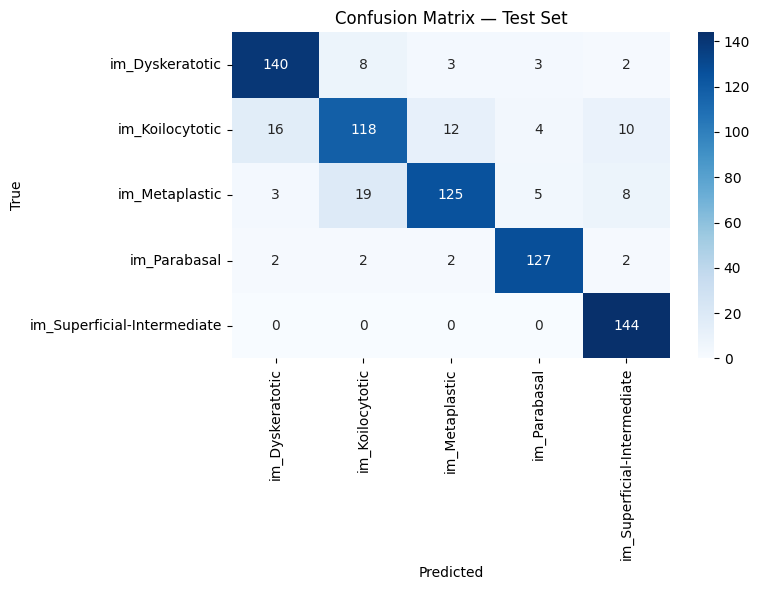

In [25]:
import torch
import sys
sys.path.insert(0, REPO_DIR)

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scripts.train_cervical import CervicalDataset, build_val_transform
from models.cervical_classifier import CervicalClassifier, CLASS_NAMES

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load best checkpoint
ckpt_path = f'{REPO_DIR}/trained_models/cervical_best.pt'

# 1. Instantiate the model without checkpoint_path
model = CervicalClassifier(pretrained=False).to(device)

# 2. Load the checkpoint state dictionary separately
checkpoint = torch.load(ckpt_path, map_location=device)
model.backbone.load_state_dict(checkpoint["model_state_dict"])

model.eval()
print('Loaded checkpoint from', ckpt_path)

# Test set
test_ds = CervicalDataset(
    f'{REPO_DIR}/data/sipakmed_split.csv', 'test', build_val_transform(224)
)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.tolist())

print('\nClassification Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/femscan_checkpoints/confusion_matrix.png', dpi=150)
plt.show()

100%|██████████| 500/500 [00:00<00:00, 1709.82it/s]


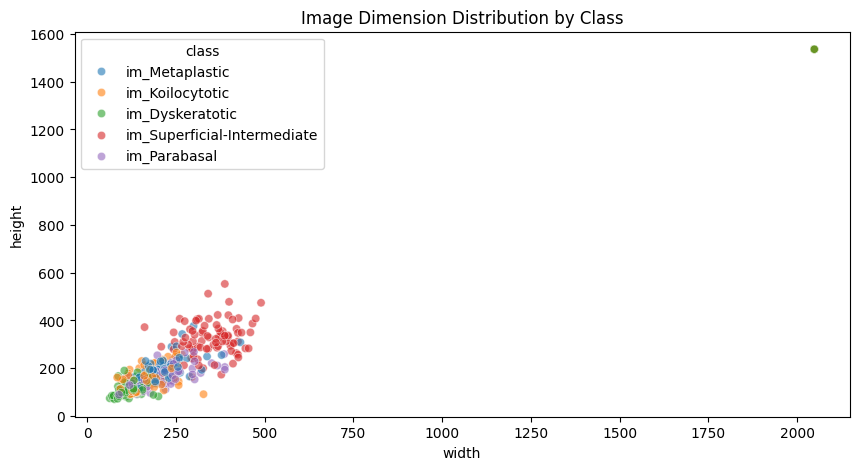

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from pathlib import Path

# Load manifest
df = pd.read_csv('/content/femscan-ai/data/sipakmed_split.csv')
PROJ = Path('/content/femscan-ai')

# Sample 500 images for speed, or remove .sample() for full EDA
sample_df = df.sample(n=min(500, len(df)))

metadata = []
for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
    img_path = PROJ / row['filepath']
    with Image.open(img_path) as img:
        width, height = img.size
        metadata.append({
            'width': width,
            'height': height,
            'aspect_ratio': width / height,
            'class': row['class'],
            'split': row['split']
        })

meta_df = pd.DataFrame(metadata)

# --- Visualize Dimensions ---
plt.figure(figsize=(10, 5))
sns.scatterplot(data=meta_df, x='width', y='height', hue='class', alpha=0.6)
plt.title("Image Dimension Distribution by Class")
plt.show()

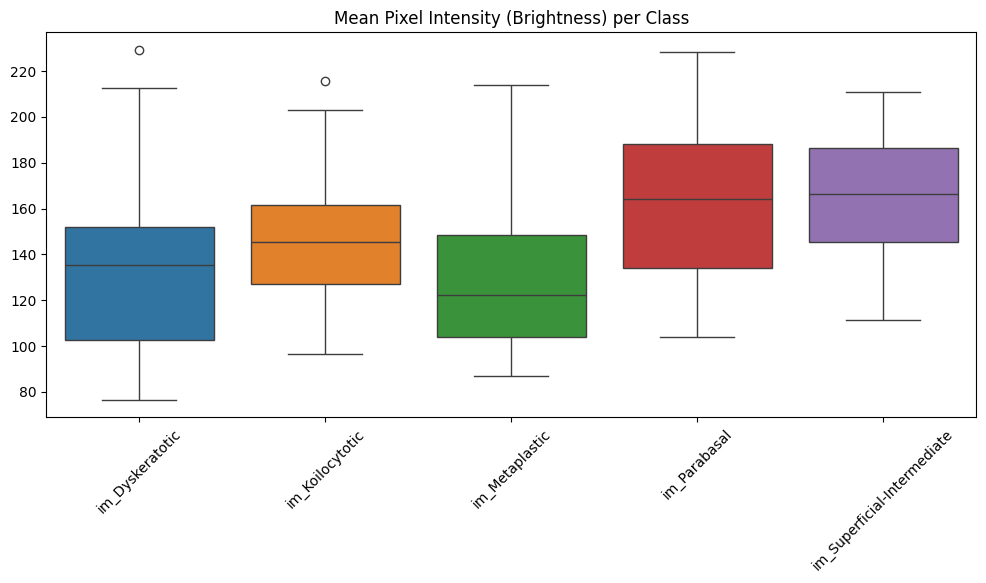

In [27]:
import cv2
import numpy as np

def get_color_stats(img_path):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return np.mean(img, axis=(0,1)), np.std(img, axis=(0,1))

# Analyze average brightness across classes
class_brightness = {}
for cls in df['class'].unique():
    subset = df[df['class'] == cls].sample(20)
    brightness_vals = [np.mean(get_color_stats(PROJ / r['filepath'])[0]) for _, r in subset.iterrows()]
    class_brightness[cls] = brightness_vals

plt.figure(figsize=(12, 5))
sns.boxplot(data=pd.DataFrame(class_brightness))
plt.title("Mean Pixel Intensity (Brightness) per Class")
plt.xticks(rotation=45)
plt.show()

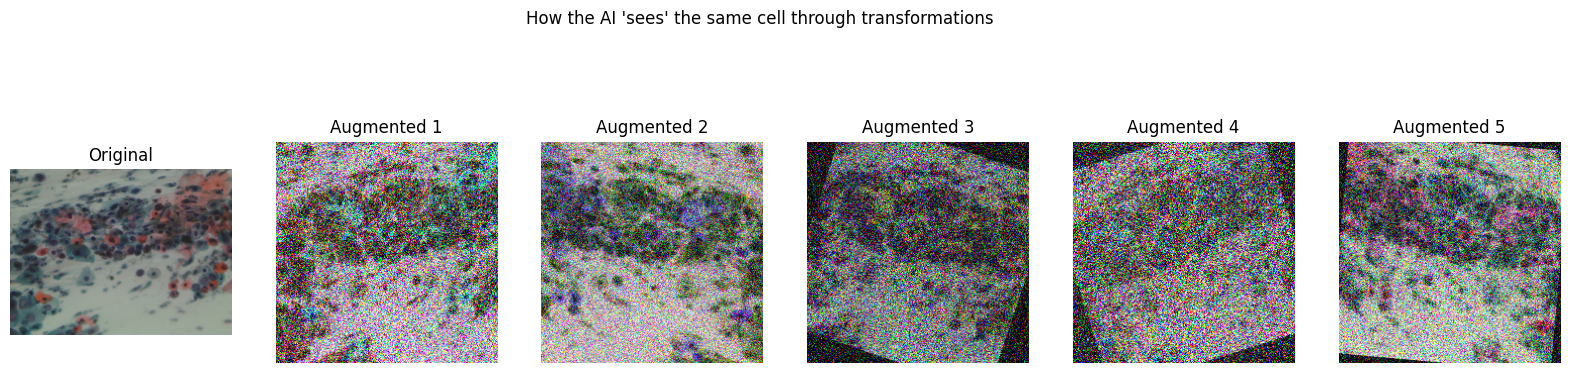

In [29]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

# This matches your EXACT training pipeline from train_cervical.py
example_transform = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, p=1.0), # Forced p=1.0 to see the effect
    A.GaussNoise(p=1.0)
])

# Pick one image and show 5 different "transformed" versions of it
sample_path = PROJ / df.iloc[0]['filepath']
raw_img = np.array(Image.open(sample_path).convert("RGB"))

fig, axes = plt.subplots(1, 6, figsize=(20, 5))
axes[0].imshow(raw_img)
axes[0].set_title("Original")
axes[0].axis('off')

for i in range(1, 6):
    aug_img = example_transform(image=raw_img)['image']
    axes[i].imshow(aug_img)
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis('off')

plt.savefig("/content/augmented.jpg")

plt.suptitle("How the AI 'sees' the same cell through transformations")
plt.show()

In [30]:
%%writefile /content/femscan-ai/app.py

import streamlit as st
import torch
import PIL.Image as Image
from pathlib import Path
import sys
from fpdf import FPDF

# Setup paths
PROJ = Path('/content/femscan-ai')
sys.path.insert(0, str(PROJ))

from models.cervical_classifier import CervicalClassifier, CLASS_NAMES, CLASS_META

# --- STYLING (Custom CSS) ---
def local_css():
    st.markdown("""
    <style>
    .main { background-color: #0e1117; }
    .stMetric { background-color: #161b22; padding: 15px; border-radius: 10px; border: 1px solid #30363d; }
    .triage-card { padding: 20px; border-radius: 15px; margin-bottom: 20px; border-left: 10px solid; }
    .urgency-high { border-left-color: #ff4b4b; background-color: #321414; }
    .urgency-moderate { border-left-color: #ffa500; background-color: #2d2412; }
    .urgency-low { border-left-color: #00c853; background-color: #0e2213; }
    </style>
    """, unsafe_allow_html=True)

# --- PDF GENERATOR ---
def create_pdf(result_name, confidence, meta, patient_id):
    pdf = FPDF()
    pdf.add_page()
    pdf.set_font("Arial", 'B', 20)
    pdf.set_text_color(40, 70, 150)
    pdf.cell(200, 20, txt="FEMSCAN AI: CLINICAL REPORT", ln=True, align='C')
    pdf.set_font("Arial", size=12)
    pdf.set_text_color(0, 0, 0)
    pdf.cell(200, 10, txt=f"Patient ID: {patient_id}", ln=True)
    pdf.cell(200, 10, txt=f"Diagnosis: {result_name}", ln=True)
    pdf.cell(200, 10, txt=f"Confidence: {confidence}", ln=True)
    pdf.ln(10)
    pdf.multi_cell(0, 10, txt=f"Recommendation: {meta['action']}")
    return pdf.output(dest='S').encode('latin-1')

# --- APP LOGIC ---
st.set_page_config(page_title="FemScan AI", page_icon="🔬", layout="wide")
local_css()

@st.cache_resource
def load_model():
    model = CervicalClassifier(pretrained=False)
    path = PROJ / "trained_models" / "cervical_best.pt"
    if not path.exists(): return None
    checkpoint = torch.load(path, map_location="cpu")
    model.backbone.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model

# --- SIDEBAR ---
with st.sidebar:
    st.image("https://cdn-icons-png.flaticon.com/512/2864/2864350.png", width=100)
    st.title("Patient Portal")
    patient_id = st.text_input("Patient ID", value="PX-9920")
    st.divider()
    st.info("System Status: Online\\nModel: EfficientNetV2-S")

# --- MAIN UI ---
st.title("🔬 FemScan AI Analysis Terminal")
st.caption("Advanced Cervical Cytology Classification System")

col_left, col_right = st.columns([1, 1])

with col_left:
    st.subheader("Step 1: Upload Sample")
    uploaded_file = st.file_uploader("", type=["bmp", "png", "jpg"])
    if uploaded_file:
        img = Image.open(uploaded_file).convert("RGB")
        st.image(img, caption="Microscopy View", use_container_width=True)

with col_right:
    st.subheader("Step 2: Automated Triage")
    if uploaded_file and st.button("🚀 Run AI Analysis", use_container_width=True):
        model = load_model()
        if model is None:
            st.error("Weights not found! Ensure training finished and 'cervical_best.pt' exists.")
        else:
            from torchvision import transforms
            tf = transforms.Compose([
                transforms.Resize(256), transforms.CenterCrop(224),
                transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
            ])

            with st.spinner("Processing morphology..."):
                input_tensor = tf(img).unsqueeze(0)
                logits = model(input_tensor)
                probs = torch.nn.functional.softmax(logits, dim=1)
                conf, pred_idx = torch.max(probs, 1)

                pred_class = CLASS_NAMES[pred_idx.item()]
                meta = CLASS_META[pred_class]
                res_name = pred_class.replace('im_', '')

                # Beautiful Result Card
                urgency_class = f"urgency-{meta['urgency']}"
                st.markdown(f"""
                <div class="triage-card {urgency_class}">
                    <h2 style='margin:0;'>{res_name}</h2>
                    <p style='font-size:1.2rem; opacity:0.8;'>Confidence Score: {conf.item():.2%}</p>
                </div>
                """, unsafe_allow_html=True)

                m1, m2 = st.columns(2)
                m1.metric("Category", meta['category'])
                m2.metric("CIN Grade", meta['cin_grade'])

                st.warning(f"**Action Required:** {meta['action']}")

                # Report Download
                pdf_data = create_pdf(res_name, f"{conf.item():.2%}", meta, patient_id)
                st.download_button("📩 Download PDF Report", data=pdf_data, file_name=f"{patient_id}_report.pdf", use_container_width=True)

Overwriting /content/femscan-ai/app.py


In [ ]:
# 1. Install necessary tools
!pip install streamlit fpdf

# 2. Run the server in the background
import subprocess
# We use nohup to keep it running even if the cell finishes
!nohup streamlit run /content/femscan-ai/app.py --server.port 8501 &

# 3. Get your "Tunnel Password" (Your Public IP)
print("COPY THIS IP ADDRESS FOR THE TUNNEL PASSWORD:")
!curl ipv4.icanhazip.com

# 4. Open the tunnel
!npx localtunnel --port 8501

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 123.4 MB/s eta 0:00:00
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40704 sha256=3d667e28627a27c4c42c0d17beb2d1af0f2e593b1817c1eccf120c90f0bc1742
  Stored in directory: /root/.cache/pip/wheels/6e/62/11/dc73d78e40a218ad52e7451f30166e94491be013a7850b5d75
Successfully built fpdf
nohup: appending output to 'nohup.out'
COPY THIS IP ADDRESS FOR THE TUNNEL PASSWORD:
34.142.188.177
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://little-months-act.loca.lt


In [ ]:
# 1. Stop any previously running Streamlit processes
# This command will list processes, then you can manually kill them if needed.
# Sometimes the 'nohup' process might need to be explicitly killed.
!pkill -f streamlit

# Wait a moment for processes to terminate (optional, but good practice)
import time
time.sleep(5)

print("Attempted to stop Streamlit processes. Now restarting.")

Attempted to stop Streamlit processes. Now restarting.


In [ ]:
# 2. Run the server again with the updated app.py
# This cell re-executes the Streamlit launch command.

# Make sure the app.py file has been correctly written by the `%%writefile` command above.

!nohup streamlit run /content/femscan-ai/app.py --server.port 8501 &

# 3. Get your "Tunnel Password" (Your Public IP)
print("COPY THIS IP ADDRESS FOR THE TUNNEL PASSWORD:")
!curl ipv4.icanhazip.com

# 4. Open the tunnel
# This will generate a new localtunnel URL for your Streamlit app.
!npx localtunnel --port 8501

nohup: appending output to 'nohup.out'
COPY THIS IP ADDRESS FOR THE TUNNEL PASSWORD:
8.228.4.31
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://forty-icons-sit.loca.lt
^C
